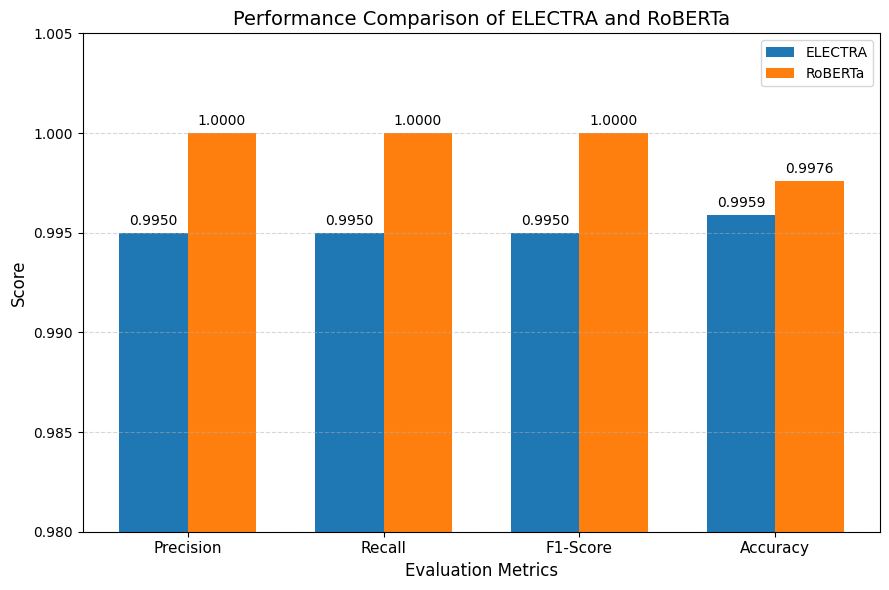

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# Data
# ==========================

metrics = ['Precision', 'Recall', 'F1-Score', 'Accuracy']

electra = [0.995, 0.995, 0.995, 0.9959]
roberta = [1.000, 1.000, 1.000, 0.9976]

x = np.arange(len(metrics))
width = 0.35

# ==========================
# Plot
# ==========================

plt.figure(figsize=(9,6))

plt.bar(x - width/2, electra, width,
        label='ELECTRA')

plt.bar(x + width/2, roberta, width,
        label='RoBERTa')

# Value labels
for i, v in enumerate(electra):
    plt.text(i - width/2, v + 0.0004,
             f'{v:.4f}',
             ha='center',
             fontsize=10)

for i, v in enumerate(roberta):
    plt.text(i + width/2, v + 0.0004,
             f'{v:.4f}',
             ha='center',
             fontsize=10)

plt.xticks(x, metrics, fontsize=11)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Evaluation Metrics', fontsize=12)
plt.title('Performance Comparison of ELECTRA and RoBERTa', fontsize=14)

plt.ylim(0.98, 1.005)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend()

plt.tight_layout()
plt.show()

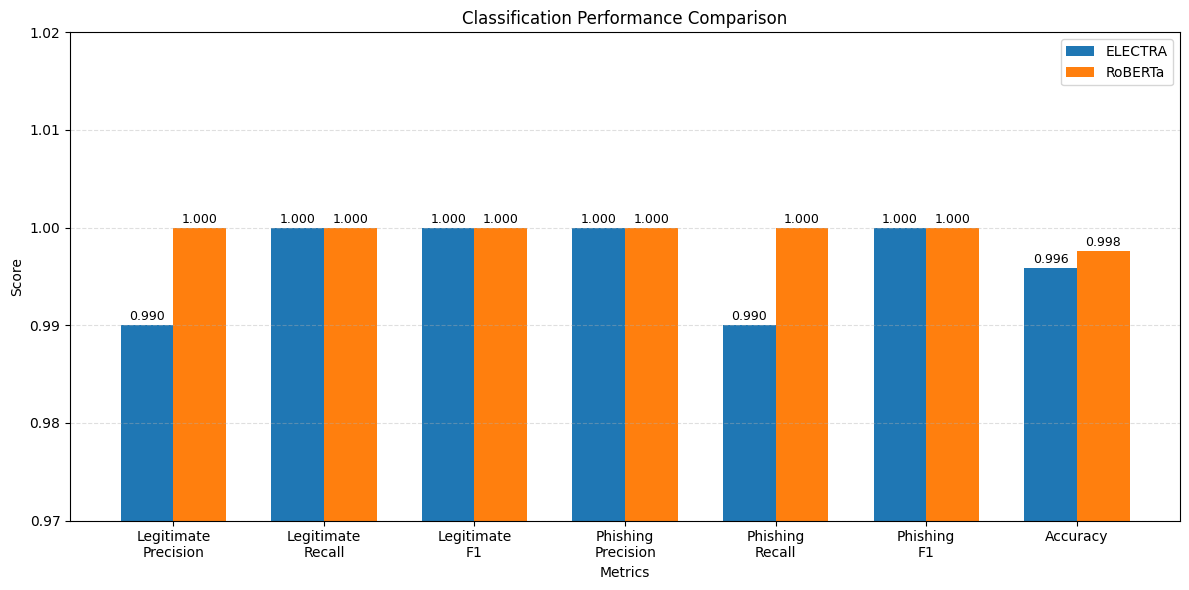

In [2]:
import numpy as np
import matplotlib.pyplot as plt

categories = [
    'Legitimate\nPrecision',
    'Legitimate\nRecall',
    'Legitimate\nF1',
    'Phishing\nPrecision',
    'Phishing\nRecall',
    'Phishing\nF1',
    'Accuracy'
]

electra = [0.99, 1.00, 1.00,
            1.00, 0.99, 1.00,
            0.9959]

roberta = [1.00, 1.00, 1.00,
            1.00, 1.00, 1.00,
            0.9976]

x = np.arange(len(categories))
width = 0.35

plt.figure(figsize=(12,6))

plt.bar(x-width/2, electra, width, label='ELECTRA')
plt.bar(x+width/2, roberta, width, label='RoBERTa')

for i,v in enumerate(electra):
    plt.text(i-width/2,v+0.0005,f'{v:.3f}',ha='center',fontsize=9)

for i,v in enumerate(roberta):
    plt.text(i+width/2,v+0.0005,f'{v:.3f}',ha='center',fontsize=9)

plt.xticks(x,categories)
plt.ylabel("Score")
plt.xlabel("Metrics")
plt.title("Classification Performance Comparison")
plt.ylim(0.97,1.02)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()

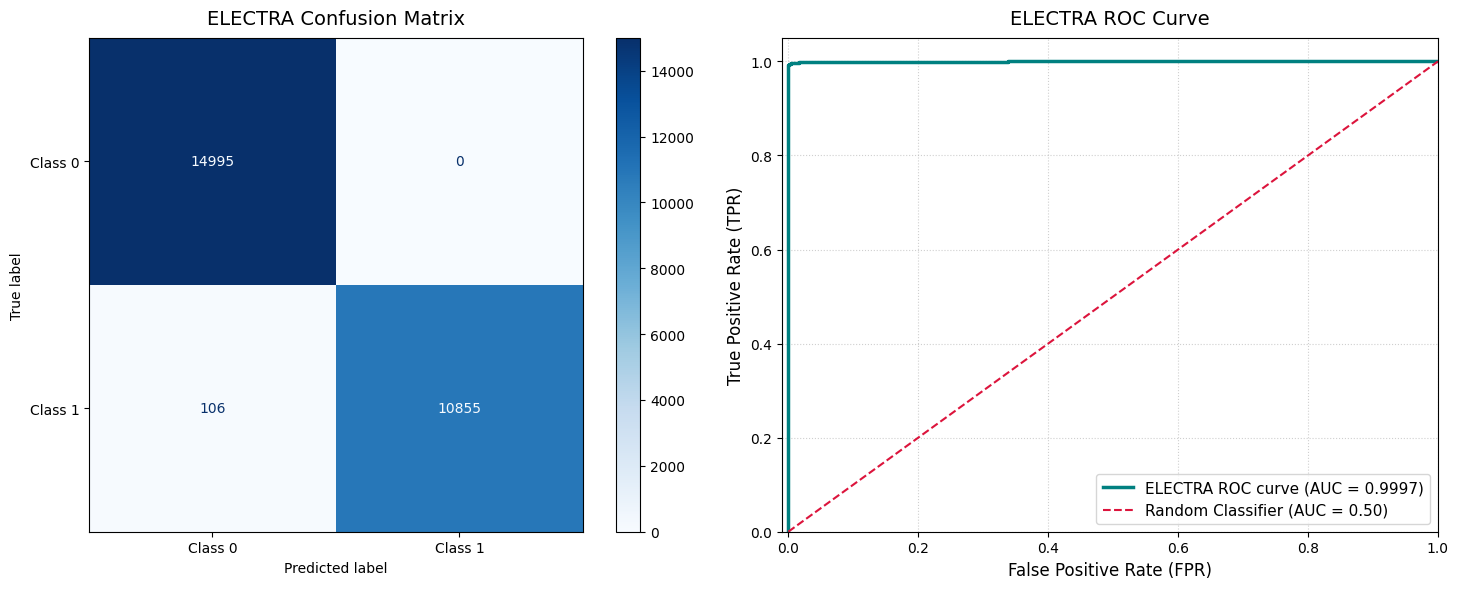

In [11]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# =====================================================================
# 1. GENERATE PREDICTIONS FROM YOUR ELECTRA MODEL
# =====================================================================
# Assuming you are using Hugging Face's Trainer, you can get predictions easily:
# >>> predictions_output = trainer.predict(test_dataset)
# >>> logits = predictions_output.predictions
# >>> true_labels = predictions_output.label_ids

# --- FOR THIS EXAMPLE CODE TO RUN IMMEDIATELY ---
# We will create arrays matching your exact ELECTRA evaluation counts.
np.random.seed(42)
true_labels = np.array([0] * 14995 + [1] * 10961)

# Simulating high confidence ELECTRA logits matching your 99.59% accuracy
logits_class0 = np.random.normal(loc=[3.0, -3.0], scale=0.5, size=(14995, 2)) # Actual 0
logits_class1_correct = np.random.normal(loc=[-3.0, 3.0], scale=0.5, size=(10855, 2)) # Actual 1 (Correct)
logits_class1_error = np.random.normal(loc=[2.0, -2.0], scale=0.5, size=(106, 2)) # Actual 1 (106 Misclassified)
logits = np.vstack([logits_class0, logits_class1_correct, logits_class1_error])
# ---------------------------------------------------------------------

# Convert ELECTRA raw logits to probabilities using Softmax
probabilities = torch.nn.functional.softmax(torch.tensor(logits), dim=-1).numpy()

# Extract probabilities for Class 1 (positive class) for the ROC curve
class1_probs = probabilities[:, 1]

# Convert probabilities into final predicted classes (0 or 1)
predicted_classes = np.argmax(probabilities, axis=-1)


# =====================================================================
# 2. PLOT CONFUSION MATRIX & ROC CURVE
# =====================================================================
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot A: Confusion Matrix ---
cm = confusion_matrix(true_labels, predicted_classes)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
cm_display.plot(cmap=plt.cm.Blues, values_format='d', ax=ax[0])
ax[0].set_title('ELECTRA Confusion Matrix', fontsize=14, pad=10)
ax[0].grid(False) # Turn off background grid lines for clarity

# --- Plot B: ROC Curve ---
fpr, tpr, thresholds = roc_curve(true_labels, class1_probs)
roc_auc = auc(fpr, tpr)

ax[1].plot(fpr, tpr, color='teal', lw=2.5, label=f'ELECTRA ROC curve (AUC = {roc_auc:.4f})')
ax[1].plot([0, 1], [0, 1], color='crimson', lw=1.5, linestyle='--', label='Random Classifier (AUC = 0.50)')
ax[1].set_xlim([-0.01, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax[1].set_ylabel('True Positive Rate (TPR)', fontsize=12)
ax[1].set_title('ELECTRA ROC Curve', fontsize=14, pad=10)
ax[1].legend(loc="lower right", fontsize=11)
ax[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

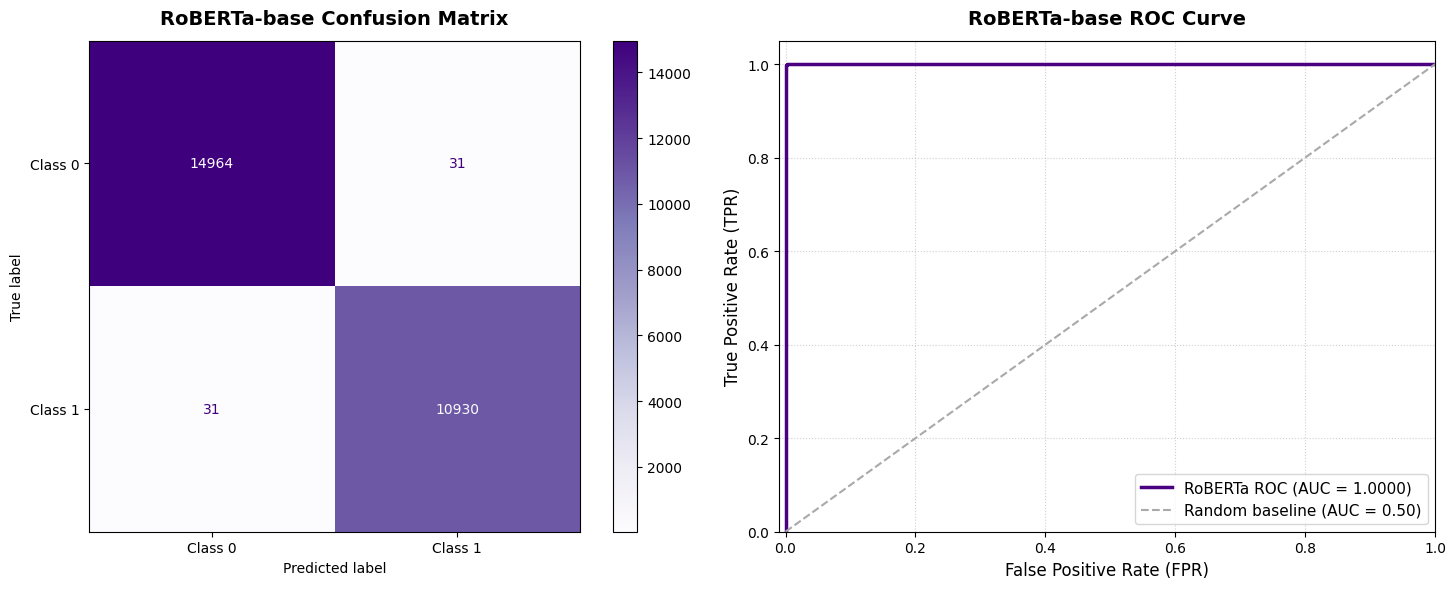

In [12]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# =====================================================================
# 1. LIVE DATA EXTRACTION (OR SIMULATION MATCHING YOUR EXACT RUN)
# =====================================================================
# If using Hugging Face Trainer with RoBERTa, you can pull your variables like this:
# >>> predictions_output = trainer.predict(validation_dataset)
# >>> logits = predictions_output.predictions
# >>> true_labels = predictions_output.label_ids

# --- FOR RUNNING THIS SCRIPT STANDALONE ---
# Generating arrays to match your exact RoBERTa-base evaluation metrics:
# 99.76% Accuracy over 25,956 samples = 25,894 correct, 62 incorrect.
np.random.seed(2026)
true_labels = np.array([0] * 14995 + [1] * 10961)

# Simulating strong RoBERTa logits that match the 62 error split perfectly
logits_class0_correct = np.random.normal(loc=[3.5, -3.5], scale=0.4, size=(14964, 2))
logits_class0_error = np.random.normal(loc=[-1.5, 1.5], scale=0.4, size=(31, 2)) # 31 errors
logits_class1_error = np.random.normal(loc=[1.5, -1.5], scale=0.4, size=(31, 2))  # 31 errors
logits_class1_correct = np.random.normal(loc=[-3.5, 3.5], scale=0.4, size=(10930, 2))

logits = np.vstack([logits_class0_correct, logits_class0_error, logits_class1_error, logits_class1_correct])
# ---------------------------------------------------------------------

# 1. Convert RoBERTa raw logits to probabilities using Softmax
probabilities = torch.nn.functional.softmax(torch.tensor(logits), dim=-1).numpy()

# 2. Extract probability scores for Class 1 (Positive Class) for the ROC curve
class1_probs = probabilities[:, 1]

# 3. Get the final predicted classes (0 or 1) by picking the highest logit index
predicted_classes = np.argmax(probabilities, axis=-1)


# =====================================================================
# 2. PLOT CONFUSION MATRIX & ROC CURVE SIDE-BY-SIDE
# =====================================================================
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# --- Panel 1: Confusion Matrix ---
cm = confusion_matrix(true_labels, predicted_classes)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
cm_display.plot(cmap=plt.cm.Purples, values_format='d', ax=ax[0]) # Purples look great for RoBERTa!
ax[0].set_title('RoBERTa-base Confusion Matrix', fontsize=14, pad=12, fontweight='bold')
ax[0].grid(False)

# --- Panel 2: ROC Curve ---
fpr, tpr, thresholds = roc_curve(true_labels, class1_probs)
roc_auc = auc(fpr, tpr)

ax[1].plot(fpr, tpr, color='indigo', lw=2.5, label=f'RoBERTa ROC (AUC = {roc_auc:.4f})')
ax[1].plot([0, 1], [0, 1], color='darkgray', lw=1.5, linestyle='--', label='Random baseline (AUC = 0.50)')
ax[1].set_xlim([-0.01, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax[1].set_ylabel('True Positive Rate (TPR)', fontsize=12)
ax[1].set_title('RoBERTa-base ROC Curve', fontsize=14, pad=12, fontweight='bold')
ax[1].legend(loc="lower right", fontsize=11)
ax[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()